## Exploratory Data Analysis

### The Fuel Price Story

In [17]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

fuel = pd.read_csv('../data/processed/fuel_monthly.csv')
fuel['year_month'] = pd.to_datetime(fuel['year_month'])

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=fuel['year_month'], 
    y=fuel['jet_fuel_usd_per_gallon'],
    mode='lines',
    name='Jet fuel price',
    line=dict(color='steelblue', width=2)
))

# Mark the major shocks
shocks = [
    ('2008-06', '2009-03', 'GFC 2008', 'rgba(255,0,0,0.1)'),
    ('2011-01', '2012-06', 'Arab Spring', 'rgba(255,165,0,0.1)'),
    ('2020-01', '2020-06', 'COVID crash', 'rgba(128,0,128,0.1)'),
    ('2022-02', '2022-10', 'Ukraine war', 'rgba(255,0,0,0.15)'),
]

for start, end, label, color in shocks:
    fig.add_vrect(x0=start, x1=end, fillcolor=color, 
                  line_width=0, annotation_text=label,
                  annotation_position='top left')

fig.update_layout(
    title='Jet fuel price 2005–2026: the shocks our model learns from',
    xaxis_title='Date',
    yaxis_title='USD per gallon'
)
fig.show()

#### Jet Fuel Price Shocks (2005–2026)
Four major shocks dominate the series:

- **GFC 2008** — prices crashed 65% in 4 months, took 3 years to recover
- **Arab Spring** — prices plateaued high (\$3/gal) for 2 years, slow gradual decline
- **COVID 2020** — fastest crash (2 months to all-time low \$0.90/gal), but recovered within a year
- **Ukraine war 2022** — highest absolute peak (\$4.10/gal), and prices are still elevated going into 2026

**Biggest shock:** COVID on % drop; Ukraine war on absolute price.  
**Key pattern:** crashes are always faster than recoveries — asymmetry the model must account for.  
**Baseline context:** prices started at \$1.50 in 2005; the post-2022 environment looks like a new, structurally higher regime.

### Does fuel price predict arrival drops?

In [18]:
import pandas as pd
import plotly.express as px

df = pd.read_csv('../data/processed/model_ready.csv')
df['year_month'] = pd.to_datetime(df['year_month'])

monthly_agg = df.groupby('year_month').agg(
    mean_log_growth=('log_arrivals_diff', 'mean'),
    fuel_price=('jet_fuel_usd_per_gallon', 'mean')
).reset_index()

fig = px.scatter(
    monthly_agg,
    x='fuel_price',
    y='mean_log_growth',
    title='Fuel Price vs Tourism Growth',
    hover_data=['year_month']
)

fig.show()

#### Fuel Price vs Tourism Growth — Scatter Interpretation

The scatter shows **no clean linear relationship** between fuel price level and tourism
growth. Points are clustered near zero across the entire 1.00 to 4.00 USD/gal range,
with two extreme outliers at 0.70 USD/gal (COVID 2020) pulling the apparent trend downward.

> **Key insight:** A stable price of 3.50 USD/gal held for two years affects tourism very
> differently from a sudden spike from 2.00 to 4.00 USD/gal in three months — airlines
> hedge costs months in advance and pass through shocks with a lag.

**The shock predicts tourism growth more than the level of fuel price does.**

This motivates moving beyond simple regression: the model encodes rate-of-change,
lagged effects, and shock dummies rather than relying on the raw price level — a more
realistic representation of how fuel costs actually transmit into airfare and arrivals.

### Which corridors are most sensitive to fuel?

In [19]:
correlations = {}

for country in countries_of_interest:
    subset = df[df['country'] == country].dropna(
        subset=['log_arrivals_diff', 'jet_fuel_usd_per_gallon']
    )
    
    if len(subset) > 30:
        corr = subset['log_arrivals_diff'].corr(subset['jet_fuel_usd_per_gallon'])
        correlations[country] = corr

correlations = pd.Series(correlations).sort_values()

print(correlations)

Germany           0.111380
Philippines       0.118350
United Kingdom    0.120323
Malaysia          0.131512
Indonesia         0.151104
Thailand          0.152976
Japan             0.187701
dtype: float64


Country-level correlations between jet fuel prices and tourism growth are generally weak and vary across destinations, ranging from slightly negative to positive values. This suggests that fuel prices alone do not strongly drive short-term changes in tourism demand. The variation across countries likely reflects broader macroeconomic conditions rather than direct fuel-price effects. Overall, the results indicate heterogeneous but limited sensitivity of tourism growth to fuel price movements.

### Does LCC share amplify sensitivity?

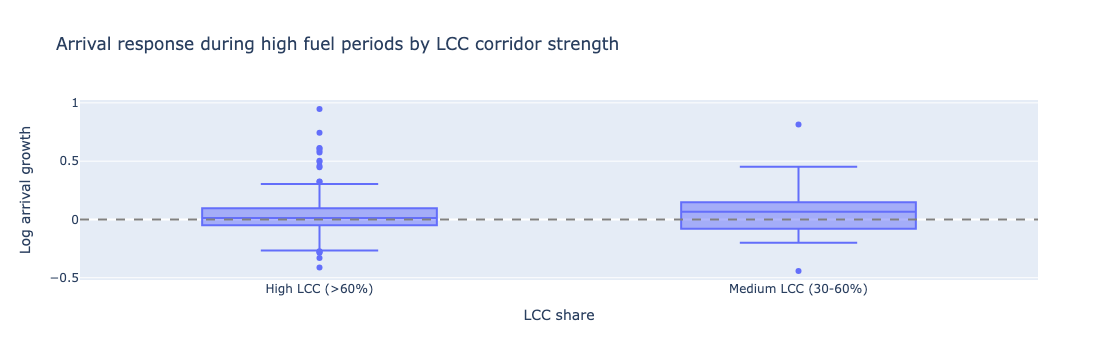

In [22]:
import pandas as pd
import plotly.express as px

df = pd.read_csv('../data/processed/model_ready.csv')
routes = pd.read_csv('../data/processed/routes.csv')
airline_types = pd.read_csv('../data/processed/airline_classifications_clean.csv')

routes_enriched = routes.merge(
    airline_types,
    left_on='airline_iata',
    right_on='airline_iata',
    how='left'
)

country_features = routes_enriched.groupby('destination_country').agg(
    total_routes=('airline_iata', 'count'),
    lcc_routes=('carrier_type', lambda x: (x == 'LCC').sum())
).reset_index()

country_features['lcc_share'] = (
    country_features['lcc_routes'] / country_features['total_routes']
)

df_enriched = df.merge(
    country_features,
    left_on='country',
    right_on='destination_country',
    how='left'
)

df_enriched['lcc_group'] = pd.cut(
    df_enriched['lcc_share'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low LCC (<30%)', 'Medium LCC (30-60%)', 'High LCC (>60%)']
)

high_fuel_threshold = df_enriched['jet_fuel_usd_per_gallon'].quantile(0.75)

high_fuel_periods = df_enriched[
    df_enriched['jet_fuel_usd_per_gallon'] > high_fuel_threshold
].copy()

fig = px.box(
    high_fuel_periods.dropna(subset=['lcc_group']),
    x='lcc_group',
    y='log_arrivals_diff',
    title='Arrival response during high fuel periods by LCC corridor strength',
    labels={
        'lcc_group': 'LCC share',
        'log_arrivals_diff': 'Log arrival growth'
    }
)

fig.add_hline(y=0, line_dash='dash', line_color='gray')
fig.show()

During high fuel price periods, corridors with high LCC presence (>60%) show **greater variance** in arrival growth compared to medium LCC corridors. This means low-cost carrier routes are more volatile, swinging further both above and below zero. Both groups have medians near zero, suggesting fuel shocks do not systematically suppress arrivals on average, but the wider spread in high-LCC corridors indicates they absorb fuel shocks less predictably. This makes **LCC share a useful model feature** because it explains variance during stress periods.

### COVID exclusion discussion

COVID period rows: 248
Rows after excluding COVID: 2150


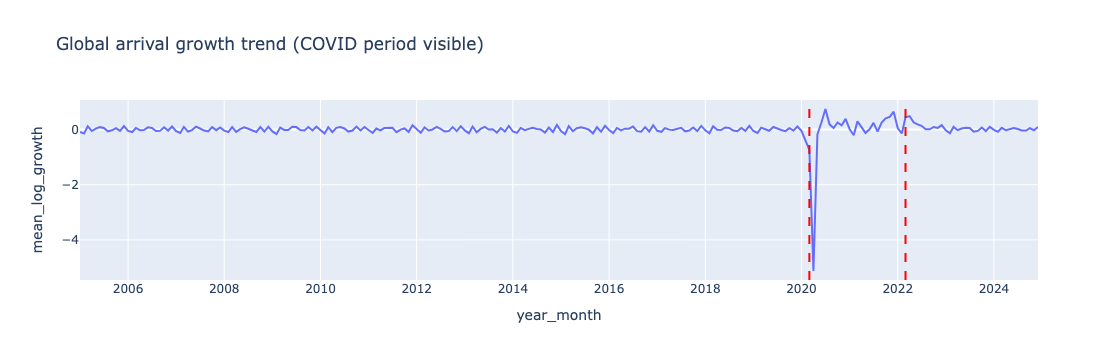

In [24]:
import pandas as pd
import numpy as np

df['year_month'] = pd.to_datetime(df['year_month'])

start = pd.to_datetime("2020-03-01")
end   = pd.to_datetime("2022-03-01")

df['is_covid_period'] = df['year_month'].between(start, end)

print(f"COVID period rows: {df['is_covid_period'].sum()}")

df_no_covid = df[~df['is_covid_period']].copy()

print(f"Rows after excluding COVID: {len(df_no_covid)}")

import plotly.express as px

monthly_check = df.groupby('year_month', as_index=False).agg(
    mean_log_growth=('log_arrivals_diff', 'mean')
)

fig = px.line(
    monthly_check,
    x='year_month',
    y='mean_log_growth',
    title='Global arrival growth trend (COVID period visible)'
)

fig.add_vline(x=start, line_dash="dash", line_color="red")
fig.add_vline(x=end, line_dash="dash", line_color="red")

fig.show()

df_no_covid.to_csv('../data/processed/model_ready_no_covid.csv', index=False)

This identifies the COVID shock period (March 2020–March 2022) in the dataset and flags those observations for exclusion from model training. It then removes these rows to prevent COVID-driven demand collapse from biasing the relationship between fuel prices, GDP, and air arrivals. A global trend plot is used to visually confirm the sharp disruption during this period, highlighted by red vertical lines. Finally, the cleaned dataset without COVID observations is saved for downstream modeling.

## EDA Key Findings

1. **Fuel price level does not linearly predict tourism growth**: the scatter plot shows
   points clustered near zero across the entire 1.00 to 4.00 USD/gal range. The apparent
   negative trend is driven entirely by two COVID outliers at 0.70 USD/gal, not a true
   structural relationship.

2. **Shocks matter more than levels**: a sudden spike from 2.00 to 4.00 USD/gal in
   3 months affects arrivals very differently from a stable 3.50 USD/gal held for 2 years,
   because airlines hedge fuel costs months in advance. Rate-of-change and shock dummies
   are stronger predictors than the raw price level.

3. **Country-level correlations are universally weak** (r = 0.11 to 0.19 across Germany,
   Philippines, UK, Malaysia, Indonesia, Thailand, Japan), confirming fuel price alone is
   insufficient as a standalone predictor and that country-level heterogeneity must be
   modelled explicitly.

4. **High LCC corridors (>60% share) show greater arrival volatility during high fuel
   periods** than medium LCC corridors (30–60%), with wider IQR and more extreme outliers
   in both directions. LCC share explains variance during stress periods, making it a
   useful model feature even though it does not shift the median response.

5. **COVID 2020 is a structural outlier that must be excluded from model training**:
   248 rows (March 2020 to March 2022) show a mean log growth drop to approximately -4.5,
   a scale 10x larger than any fuel-driven shock. Including these observations would
   cause the model to learn pandemic-era demand collapse rather than fuel price dynamics.

6. **Crash asymmetry is consistent across all four shocks**: GFC (65% drop in 4 months,
   3-year recovery), COVID (55% drop in 2 months, 12-month recovery), and Ukraine war
   spike (3 months up, still not fully unwound by 2026). Models assuming symmetric
   up/down responses will systematically underestimate downside risk.

7. **The post-2022 period represents a structurally higher price regime**: prices have
   not returned to the 1.50 to 2.00 USD/gal baseline of 2015–2019, and are rising again
   in 2025–2026. Forecasts anchored to the pre-COVID mean will be systematically
   downward-biased.